In [1]:
!nvidia-smi

Fri Mar 21 19:59:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:10:1C.0 Off |                    0 |
| N/A   38C    P0             58W /  400W |       1MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model and tokenizer
MODEL_NAME = "Qwen/QwQ-32B-Preview"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    output_attentions=True,  # Ensure model outputs attention maps
    trust_remote_code=True
)
model.eval()


# from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig


# MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# model = AutoModelForCausalLM.from_pretrained(
#     MODEL_NAME,
#     device_map="balanced",
#     quantization_config=BitsAndBytesConfig(load_in_8bit=True),
# )



/fsx/ubuntu/miniconda3/envs/task-vector/lib/python3.9/site-packages/transformers/generation/configuration_utils.py:818: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(
Loading checkpoint shards:  76%|█████████████████████████████████████████████████████████████████████████████████████▋                          | 13/17 [00:54<00:10,  2.73s/it]

In [4]:
import pandas as pd
import pandas as pd
COT_CUES = {
    "is_backtracking": ["Wait", "Let’s reconsider", "On second thought",
        "a better approach", "recalculating", "I made a mistake",
        "incorrect", "should have been", "Let’s try again"],
    "is_deduction": ["Therefore", "This implies", "Hence", "Thus", "It follows that"],
    "is_verification": ["Let me check", "verifying", "rechecking", "confirming", "This simplifies to"],
    "is_uncertain": ["I think", "maybe", "probably", "not sure", "this might be"],
    "is_step_by_step": ["First", "Then", "Next", "Finally", "Let’s break it down"],
    "is_heuristic_shortcut": ["quick trick", "shortcut", "we can estimate", "approximate"],
}

# Load the dataset
df = pd.read_parquet("qwq_math_results_suffixed/qwq_math_results.parquet")

# Initialize new columns
df["cot_reasoning_key"] = None
df["cot_reasoning_value"] = None

# Function to find the first matching key-value pair
def find_cot_cue(text):
    for key, values in COT_CUES.items():
        for value in values:
            if value in text:
                return key, value
    return None, None

# Apply function to each row
df[["cot_reasoning_key", "cot_reasoning_value"]] = df["model_response"].apply(lambda x: pd.Series(find_cot_cue(x)))
df["prefill"] = df["problem"] + " Please reason step by step, and put your final answer within \\boxed{}." + df["model_response"]

print(len(df))
df.head(n=10)

1040


,uuid,problem,model_response,cot_reasoning_key,cot_reasoning_value,prefill
0,586fd646-76d6-5070-8c81-9993ab9d8559,## Task B-1.3.\n\nA ship traveling along a riv...,"To solve this problem, we need to determine th...",is_step_by_step,First,## Task B-1.3.\n\nA ship traveling along a riv...
1,1d57f4b3-c516-5522-91cc-a60dd91f6f66,3. (6 points) A construction company was build...,"To solve this problem, let's denote the origin...",is_deduction,Therefore,3. (6 points) A construction company was build...
2,1cd82e3d-2e7a-5eca-9571-62f5669824c4,Prove that number $1$ can be represented as a ...,"To solve this problem, we need to represent th...",is_deduction,Therefore,Prove that number $1$ can be represented as a ...
3,ea24dff6-9e4d-5c55-9ec0-c4d55424997a,4. Given the three sides of an obtuse triangle...,To determine the range of values for \( x \) i...,is_deduction,Therefore,4. Given the three sides of an obtuse triangle...
4,a583d65c-9b4c-56ce-8263-47edbc22baa3,1. Solve the equation: $\frac{8 x+13}{3}=\frac...,2. Solve the equation: $\frac{2 x-1}{3}+\frac{...,None,None,1. Solve the equation: $\frac{8 x+13}{3}=\frac...
5,79e837be-2801-5a6a-bc7a-0acee3cdd5fd,A right-angled triangle has side lengths that ...,To determine the possible last digits of the a...,is_deduction,Therefore,A right-angled triangle has side lengths that ...
6,167ecbbb-4270-534f-afa5-75d01d968ab5,Let $a_n\ (n\geq 1)$ be the value for which $\...,To find the limit \(\lim_{n\to\infty} \ln a_n\...,is_deduction,Therefore,Let $a_n\ (n\geq 1)$ be the value for which $\...
7,84f224e8-719b-5b42-a410-27816014bdd3,"11. Given that the internal angles $A, B, C$ o...","To solve the given problem, we need to find th...",is_deduction,Thus,"11. Given that the internal angles $A, B, C$ o..."
8,f769fc87-fed5-5b73-8403-372cdd409800,Task B-4.2. Let $n$ be the number obtained by ...,To solve the equation \( x^4 = n \) where \( n...,is_deduction,Therefore,Task B-4.2. Let $n$ be the number obtained by ...
9,2a4c0374-d9ea-538e-8e0f-0811359d6cf6,"6. As shown in Figure 2, let $P$ be a point in...","To solve this problem, we need to find the are...",is_deduction,Therefore,"6. As shown in Figure 2, let $P$ be a point in..."


In [6]:
# model

In [7]:
sampled_df = (
    df[df["cot_reasoning_key"].notna()]
    .drop_duplicates(subset=["cot_reasoning_key", "cot_reasoning_value"])
    .groupby("cot_reasoning_key")
    .head(10)  # Take at most 2 unique (key, value) pairs per key
)

sampled_df


,uuid,problem,model_response,cot_reasoning_key,cot_reasoning_value,prefill
0,586fd646-76d6-5070-8c81-9993ab9d8559,## Task B-1.3.\n\nA ship traveling along a riv...,"To solve this problem, we need to determine th...",is_step_by_step,First,## Task B-1.3.\n\nA ship traveling along a riv...
1,1d57f4b3-c516-5522-91cc-a60dd91f6f66,3. (6 points) A construction company was build...,"To solve this problem, let's denote the origin...",is_deduction,Therefore,3. (6 points) A construction company was build...
7,84f224e8-719b-5b42-a410-27816014bdd3,"11. Given that the internal angles $A, B, C$ o...","To solve the given problem, we need to find th...",is_deduction,Thus,"11. Given that the internal angles $A, B, C$ o..."
14,96c9bf5f-cffe-505b-80c0-e679e10d2cf9,"Example 6 The rules of a ""level-up game"" stipu...","To solve this problem, we need to address two ...",is_backtracking,Wait,"Example 6 The rules of a ""level-up game"" stipu..."
60,e93a8cbd-336b-5aa7-9e39-b81d5037510d,4.206 There are two forces $f_{1}$ and $f_{2}$...,"To solve this problem, we need to work with ve...",is_heuristic_shortcut,approximate,4.206 There are two forces $f_{1}$ and $f_{2}$...
68,05c6feba-c571-5253-9e7a-a43d0032fefc,"In a stairwell, there are 10 mailboxes. One di...","To solve this problem, we need to calculate th...",is_backtracking,a better approach,"In a stairwell, there are 10 mailboxes. One di..."
82,a62b9e76-5993-59bd-81e5-342b61459c26,"15. As shown in the figure, the area of square...","To solve this problem, we need to find the are...",is_step_by_step,Then,"15. As shown in the figure, the area of square..."
130,33d55892-4916-5da3-a46d-d4c242e74b6b,"5. Let the complex numbers $z_{1}, z_{2}$ sati...",Let's tackle this problem step by step. We hav...,is_verification,This simplifies to,"5. Let the complex numbers $z_{1}, z_{2}$ sati..."
139,986c0e87-ff9d-53be-8035-c9ef57638b9e,"2. On a line, several points were marked, incl...","To solve this problem, we need to determine th...",is_deduction,This implies,"2. On a line, several points were marked, incl..."
163,2eb4e013-b730-5f3f-bbad-8f472adff0fb,"$9 \cdot 6$ For $a>b>c>0, \quad m>n>0(m, n$ ar...","To solve this problem, we need to analyze the ...",is_backtracking,incorrect,"$9 \cdot 6$ For $a>b>c>0, \quad m>n>0(m, n$ ar..."


In [15]:
# 

Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [01:30<00:00, 45.47s/it]


In [16]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear8bitLt(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): Lla

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Load model in eager mode to get attention ---
model_name = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    attn_implementation="eager",
    device_map="auto"
)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(model_name)


Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:25<00:00, 12.69s/it]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [8]:
# --- Input prompt ---
# message containing Wait
index = 14
message = df["prefill"][index]
uuid = df["uuid"][index]

prompt = message
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# --- Forward pass with attention ---
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# --- Stack attention into [layers, heads, seq, seq] ---
attn_list = outputs.attentions  # list of [1, heads, seq, seq]
attn_tensor = torch.stack(attn_list).squeeze(1)  # [layers, heads, seq, seq]

num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads


`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


In [16]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- Input prompt ---
index = 14
message = df["prefill"][index]
uuid = df["uuid"][index]

prompt = message
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# --- Forward pass with attention ---
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# --- Stack attention into [layers, heads, seq, seq] ---
attn_list = outputs.attentions  # list of [1, heads, seq, seq]
attn_tensor = torch.stack(attn_list).squeeze(1)  # [layers, heads, seq, seq]

# --- Get config info ---
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads
seq_len = attn_tensor.shape[-1]

# --- Flatten attention maps: [layers * heads, seq * seq] ---
# attn_vectors = attn_tensor.reshape(num_layers * num_heads, seq_len * seq_len).cpu().numpy()
attn_vectors = attn_tensor.reshape(num_layers * num_heads, seq_len * seq_len).to(torch.float32).cpu().numpy()

# --- PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(attn_vectors)

# --- Plot ---
palette = sns.color_palette("husl", num_layers)

plt.figure(figsize=(10, 10))
for i in range(num_layers * num_heads):
    layer = i // num_heads
    head = i % num_heads
    plt.scatter(X_pca[i, 0], X_pca[i, 1], color=palette[layer], label=f"Layer {layer}" if head == 0 else "", alpha=0.7)

# Remove duplicate labels in legend
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), title="Layer")

plt.title("PCA of Attention Heads Colored by Layer")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()


OutOfMemoryError: CUDA out of memory. Tried to allocate 13.85 GiB. GPU 0 has a total capacity of 39.38 GiB of which 10.61 GiB is free. Including non-PyTorch memory, this process has 28.76 GiB memory in use. Of the allocated memory 21.13 GiB is allocated by PyTorch, and 7.14 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

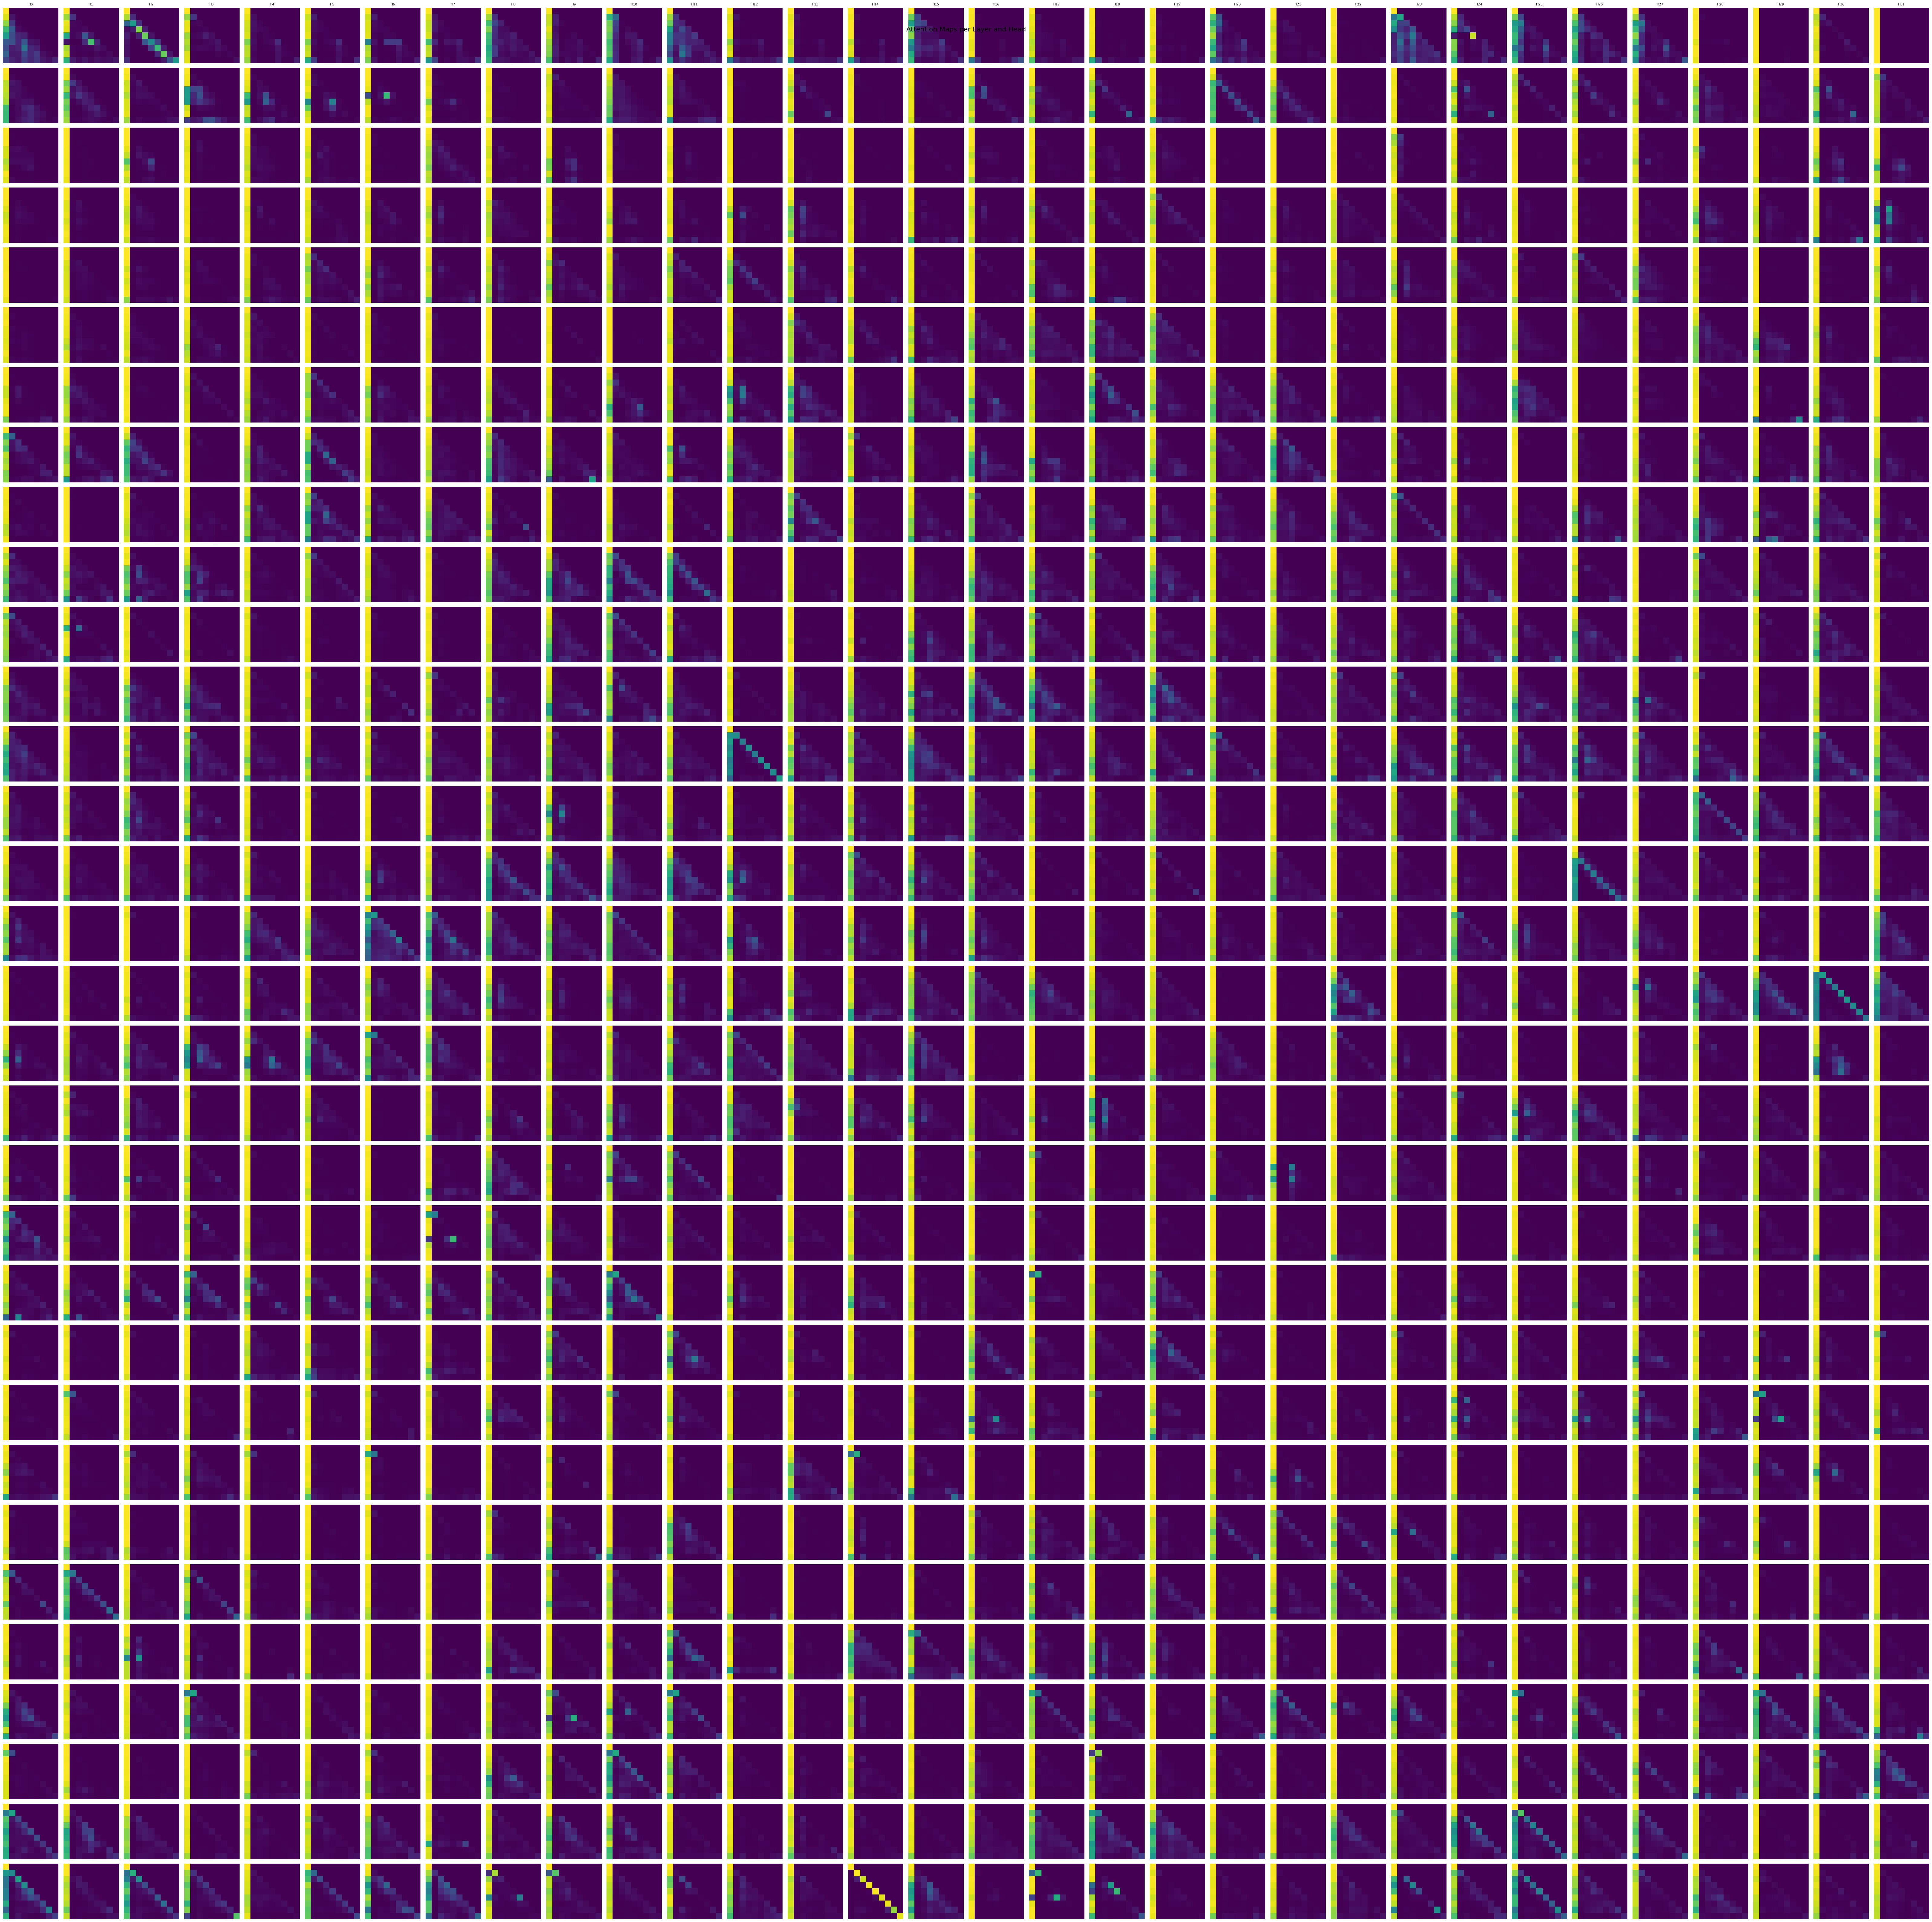

In [33]:
fig, axes = plt.subplots(num_layers, num_heads, figsize=(2 * num_heads, 2 * num_layers))

for layer in range(num_layers):
    for head in range(num_heads):
        ax = axes[layer, head]
        attn = attn_tensor[layer, head].cpu().numpy()
        ax.imshow(attn, cmap='viridis')
        ax.axis("off")
        if layer == 0:
            ax.set_title(f"H{head}", fontsize=8)
        if head == 0:
            ax.set_ylabel(f"L{layer}", fontsize=8)

plt.suptitle("Attention Maps per Layer and Head", fontsize=16)
plt.tight_layout()
plt.show()


Number of components to explain 95% of the variance: 13


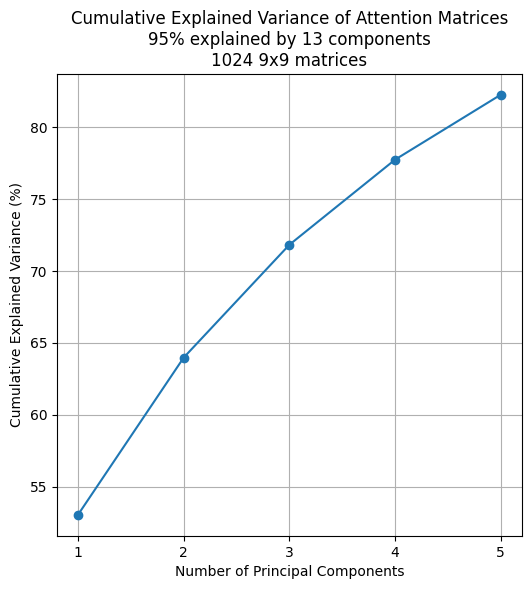

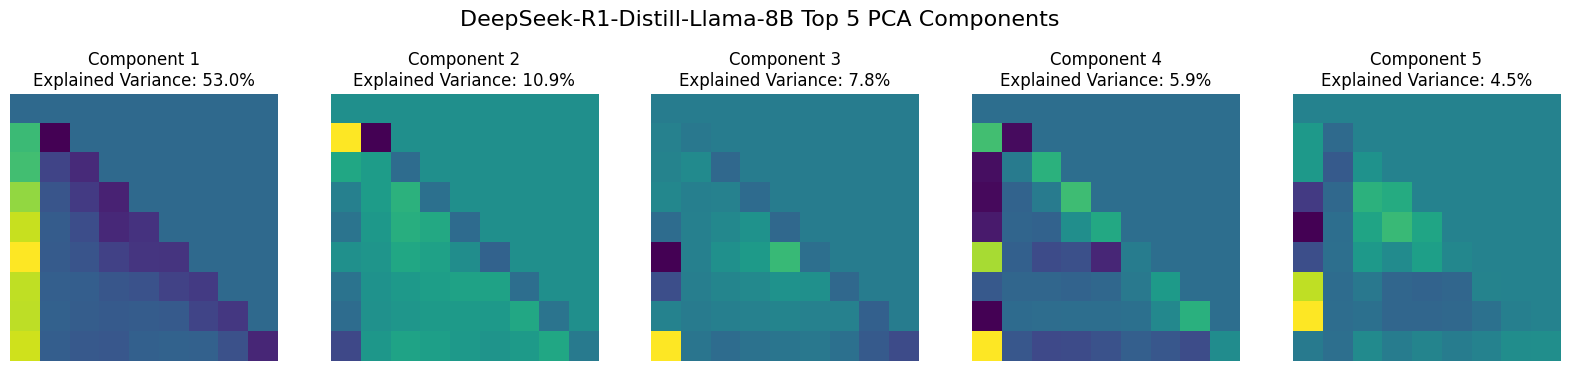

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_pca_variance(attentions, top_k=5):
    """
    Compute and plot the cumulative explained variance from PCA on attention matrices.
    
    Parameters:
    - attentions: numpy array of shape (num_layers, num_attention_heads, S, S)
    - top_k: number of components to plot
    """
    num_layers, num_attention_heads, S, _ = attentions.shape
    total_heads = num_layers * num_attention_heads

    # Apply PCA
    # Flatten each S x S matrix into a vector of length S*S
    flattened_attentions = attentions.reshape(total_heads, S*S)
    pca = PCA()
    pca.fit(flattened_attentions)

    # Compute cumulative explained variance
    explained_variance_ratio = pca.explained_variance_ratio_ * 100 # convert to percentage
    cumulative_variance = np.cumsum(explained_variance_ratio)

    # Find the number of components needed to explain 95% of the variance
    num_components_95 = np.argmax(cumulative_variance >= 95) + 1
    print(f"Number of components to explain 95% of the variance: {num_components_95}")

    # Plot the cumulative explained variance
    plot_up_to_component = 5
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(cumulative_variance[:plot_up_to_component], linestyle='-', color='tab:blue', marker='o')
    ax.set_xlabel('Number of Principal Components')
    ax.set_ylabel('Cumulative Explained Variance (%)')
    ax.set_title(f'Cumulative Explained Variance of Attention Matrices\n95% explained by {num_components_95} components\n{total_heads} {S}x{S} matrices')
    # x ticks only at integer locations and start at 0 but labeled as 1
    ax.set_xticks(np.arange(0, plot_up_to_component))
    ax.set_xticklabels(np.arange(1, plot_up_to_component+1))
    ax.grid(True)

    # Plot the top k components
    fig, ax = plt.subplots(1, top_k, figsize=(20, 4.5))
    fig.suptitle(f'{MODEL_NAME.split("/")[-1]} Top {top_k} PCA Components', fontsize=16)
    # Get abs max value for color normalization
    # max_val = np.max(np.abs(pca.components_[:top_k]))
    for i in range(top_k):
        ax[i].imshow(pca.components_[i].reshape(S, S), cmap='viridis')
        ax[i].set_title(f"Component {i+1}\nExplained Variance: {explained_variance_ratio[i]:.1f}%")
        ax[i].axis('off')

# Run the function
attentions = torch.concat(outputs.attentions, dim=0).cpu().numpy()
# Ensure no values are nan
assert not np.isnan(attentions).any(), "Some attention values are NaN"
plot_pca_variance(attentions)

In [21]:
from monkey_patch_llama import MyLlamaAttention  
from transformers.models.llama.configuration_llama import LlamaConfig 

def patch_model_attention_layers(model, PatchedAttentionClass, **kwargs):
    for i, layer in enumerate(model.model.layers):
        old_attn = layer.self_attn
        new_attn = PatchedAttentionClass(model.config, layer_idx=i, **kwargs)
        new_attn.load_state_dict(old_attn.state_dict(), strict=False)
        layer.self_attn = new_attn


patch_model_attention_layers(model, MyLlamaAttention, save_value_states=False, construct_dormant=False)


In [22]:
attn = model.model.layers[15].self_attn.saved_attn_weights
# attn shape: (batch, heads, seq, seq)


In [ ]:
# --- Step 3: Prepare inputs ---
examples = [
    "The cat sat on the mat.",
    "A robot learned how to juggle.",
    "Today is a beautiful day in San Francisco.",
    "Artificial intelligence is transforming the world.",
]

inputs = tokenizer(examples, return_tensors="pt", padding=True, truncation=True).to(model.device)
with torch.no_grad():
    _ = model(**inputs)

# --- Step 4: Extract attention from chosen layer ---
layer_idx = int(len(model.model.layers) * 0.6)
attn = model.model.layers[layer_idx].self_attn.saved_attn_weights  # (B, heads, S, S)

# --- Step 5: Flatten for PCA ---
B, H, S, _ = attn.shape
attn_flat = attn.mean(dim=2)  # (B, H, S) → avg over tokens attended *to*
attn_flat = attn_flat.reshape(B, -1).cpu().numpy()  # (B, H * S)


In [ ]:
len(sampled_df)

In [ ]:
!pip install einops

In [ ]:
import jaxtyping

import random

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer, BitsAndBytesConfig

import einops

from tqdm import tqdm

torch.inference_mode()

MODEL_ID = "stabilityai/stablelm-2-zephyr-1_6b"
#MODEL_ID = "Qwen/Qwen1.5-1.8B-Chat"
#MODEL_ID = "Qwen/Qwen-1_8B-chat"
#MODEL_ID = "google/gemma-1.1-2b-it"
#MODEL_ID = "google/gemma-1.1-7b-it"
#MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, trust_remote_code=True, torch_dtype=torch.float16, quantization_config=BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16), device_map={"": "cuda:1"})
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# settings:
instructions = 10
layer_idx = int(len(model.model.layers) * 0.6)
pos = -1

print("Instruction count: " + str(instructions))
print("Layer index: " + str(layer_idx))

with open("harmful.txt", "r") as f:
    harmful = f.readlines()

with open("harmless.txt", "r") as f:
    harmless = f.readlines()

harmful_instructions = random.sample(harmful, instructions)
harmless_instructions = random.sample(harmless, instructions)

harmful_toks = [
    tokenizer.apply_chat_template(conversation=[{"role": "user", "content": insn}], add_generation_prompt=True,
                                  return_tensors="pt") for insn in harmful_instructions]
harmless_toks = [
    tokenizer.apply_chat_template(conversation=[{"role": "user", "content": insn}], add_generation_prompt=True,
                                  return_tensors="pt") for insn in harmless_instructions]

max_its = instructions*2
bar = tqdm(total=max_its)

def generate(toks):
    bar.update(n=1)
    return model.generate(toks.to(model.device), use_cache=False, max_new_tokens=1, return_dict_in_generate=True, output_hidden_states=True)

harmful_outputs = [generate(toks) for toks in harmful_toks]
harmless_outputs = [generate(toks) for toks in harmless_toks]

bar.close()

harmful_hidden = [output.hidden_states[0][layer_idx][:, pos, :] for output in harmful_outputs]
harmless_hidden = [output.hidden_states[0][layer_idx][:, pos, :] for output in harmless_outputs]

print(harmful_hidden)

harmful_mean = torch.stack(harmful_hidden).mean(dim=0)
harmless_mean = torch.stack(harmless_hidden).mean(dim=0)

print(harmful_mean)

refusal_dir = harmful_mean - harmless_mean
refusal_dir = refusal_dir / refusal_dir.norm()

print(refusal_dir)

torch.save(refusal_dir, MODEL_ID.replace("/", "_") + "_refusal_dir.pt")

## Plotting Full Attention Map

The attention matrix only contains the tokens in the input sequence, not the entire vocabulary.

1. Structure of the Attention Matrix
2. Shape: (num_heads, seq_len, seq_len)
3. The rows correspond to tokens attending to other tokens.
4. The columns correspond to tokens being attended to.
5. Each entry represents how much attention a token in the row gives to a token in the column.

It only includes tokens present in the input sequence (i.e., tokens in inputs.input_ids). for all positions in the input. It shows how each token attends to every other token in that sequence.

In [1]:
import torch
import torch.nn as nn
from transformers.models.llama.modeling_llama import LlamaAttention

# Modify LlamaAttention to save attention weights
class MyDeepSeekAttention(LlamaAttention):
    def __init__(self, config, layer_idx: int):
        super().__init__(config, layer_idx)
        self.saved_attn_weights = None  # Store attention weights

    def forward(
        self,
        hidden_states: torch.Tensor,
        position_embeddings,
        attention_mask: torch.Tensor,
        past_key_value=None,
        cache_position=None,
        **kwargs,
    ):
        attn_output, attn_weights = super().forward(
            hidden_states,
            position_embeddings,
            attention_mask,
            past_key_value,
            cache_position,
            **kwargs,
        )
        self.saved_attn_weights = attn_weights  # Save attention weights for later
        return attn_output, attn_weights


# Patch the model with the new attention layer
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.models.llama.modeling_llama import LlamaModel

def patch_deepseek():
    for layer in model.model.layers:
        layer.self_attn = MyDeepSeekAttention(model.config, layer.layer_idx)  # Replace with custom attention



In [2]:
harmful_attn_maps = []
harmless_attn_maps = []

def generate_with_attn(toks):
    output = model.generate(
        toks.to(model.device),
        use_cache=False,
        max_new_tokens=1,
        return_dict_in_generate=True,
        output_hidden_states=True
    )
    attn_map = model.model.layers[layer_idx].self_attn.saved_attn_weights
    return output, attn_map

harmful_outputs = []
harmless_outputs = []

for toks in harmful_toks:
    out, attn = generate_with_attn(toks)
    harmful_outputs.append(out)
    harmful_attn_maps.append(attn)

for toks in harmless_toks:
    out, attn = generate_with_attn(toks)
    harmless_outputs.append(out)
    harmless_attn_maps.append(attn)



NameError: name 'harmful_toks' is not defined

In [ ]:

def plot_full_attention_map(attn_matrix, tokens, save_path, title):
    """
    Plots the full attention heatmap where both axes contain the same tokens.
    """
    # Get max attention value
    max_attn_value = np.max(attn_matrix)
    
    plt.figure(figsize=(20, 20))  # Adjust figure size
    # sns.heatmap(attn_matrix, xticklabels=tokens, yticklabels=tokens, cmap="Blues", annot=False)
    
    ax = sns.heatmap(
        attn_matrix, 
        # xticklabels=tokens, 
        # yticklabels=tokens, 
        cmap="Blues", 
        annot=False, 
        vmin=0, vmax=max_attn_value,  # Fix min and max
        cbar_kws={
            "shrink": 0.9,  # Make color bar thinner
            "aspect": 20,   # Adjust aspect ratio
            "ticks": np.linspace(0, max_attn_value, num=6)  # Ensure max value is a tick
        }
    )

    plt.title(title)
    plt.xlabel("Tokens Attended To")
    plt.ylabel("Tokens Attending")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    # Save if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved attention map to {save_path}")

    # plt.show()


In [ ]:
# Define the file path
file_path = f'full_attention_maps/{uuid}/prefill.txt'
os.makedirs(f'full_attention_maps/{uuid}')
# Save to a text file
with open(file_path, "w", encoding="utf-8") as f:
    f.write(message)

In [ ]:
# message containing Wait
index = 14
message = df["prefill"][index]
uuid = df["uuid"][index]
# layer_idx = 48
# head = 38


# Define which layers to extract attention from
num_layers = len(outputs.attentions)
layer_indices = [0, num_layers // 4, num_layers // 2, 3 * num_layers // 4, -1]  # First, 25%, 50%, 75%, Last layer

# Iterate over the selected layers
for layer_idx in layer_indices:
    print(f"Extracting attention from layer {layer_idx} of {num_layers} layers...")
    for head in range(40):
        
        # Enable output of attention weights
        inputs = tokenizer(message, return_tensors="pt").to(model.device)
        
        with torch.no_grad():  # No gradients needed for inference
            outputs = model(
                **inputs,
                output_attentions=True,  # Enables attention matrix extraction
                return_dict=True
            )
        
        # Get the last layer's attention (Shape: [batch_size, num_heads, seq_len, seq_len])
        # layer_idx = -1
        layer_attentions = outputs.attentions[layer_idx]  
        
        # Ensure we extract only the sequence length
        seq_len = layer_attentions.shape[-1]  
        print(f"Sequence length: {seq_len}")
        
        # Remove batch dimension (Shape → [num_heads, seq_len, seq_len])
        layer_attentions = layer_attentions.squeeze(0)  
        
        # Select head 38 (Shape → [seq_len, seq_len])
        head_38_attn = layer_attentions[head]  
        
        
        # Convert token IDs to readable tokens
        tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
        focus_idx_start = 0
        focus_idx_end = seq_len - 1

        # Remove unwanted tokens & update the focus index
        reduced_attn_matrix, reduced_tokens, new_focus_idx_start, new_focus_idx_end = remove_unwanted_tokens(
            tokens, head_38_attn, focus_idx_start, focus_idx_end
        )
        reduced_attn_matrix = reduced_attn_matrix[new_focus_idx_start:new_focus_idx_end, new_focus_idx_start:new_focus_idx_end]  # Extract windowed attention
        
        # Clean tokens for visualization
        cleaned_tokens = clean_tokens(reduced_tokens)
        len(cleaned_tokens)
        
        save_dir = f'full_attention_maps/{uuid}/{layer_idx}'
        save_path =  os.path.join(save_dir, f"layer_{layer_idx}_head_{head}.png")
        
        os.makedirs(save_dir, exist_ok=True)

        title = f'Layer {layer_idx} | Head {head}'
        
        
        # # Plot the full attention map
        plot_full_attention_map(reduced_attn_matrix, cleaned_tokens, save_path, title)


## Plotting Attention Map For Only Focus Tokens + Window

In [ ]:
import os
# Iterate through each sampled example
for idx, row in sampled_df.iterrows():
    # row = df.iloc[0]  # Get the first row
    
    # Access values from the first row
    reasoning_key = row["cot_reasoning_key"]
    reasoning_value = row["cot_reasoning_value"]
    uuid = row["uuid"]
    input_text = row["prefill"]
    
    # print(reasoning_key, reasoning_value, uuid, input_text)
    
    
    # Tokenize and get model outputs
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True, return_dict=True)
    
    # Extract attention maps from last layer
    attentions = outputs.attentions[-1]  # Last layer attention
    attentions = attentions.cpu().to(torch.float32).numpy()
    print(len(attentions), len(attentions[0]))
    print("attentions shape: ", np.shape(attentions))
    # attn_matrix = attentions[0].mean(axis=0)  # Average over all heads, shape: (1024, 1024)
    # attn_matrix = attn_matrix[0]
    attn_matrix = attentions[0, 0]  # [batch_idx, head_idx, seq_len, seq_len]
    print(np.shape(attn_matrix))
    
    
    # Define cue
    cue = reasoning_value if pd.notna(reasoning_value) else None
    tokens, cue_indices = find_cue_indices(tokenizer, input_text, cue)
    
    
    print(f"Processing UUID: {uuid}, Cue: {cue}")
    print("Cue Indices:", cue_indices)
    
    for focus_idx_start, focus_idx_end in cue_indices:
        print(f"Focus Index Start: {focus_idx_start}, End: {focus_idx_end}")
    
        # Remove unwanted tokens & update the focus index
        reduced_attn_matrix, reduced_tokens, new_focus_idx_start, new_focus_idx_end = remove_unwanted_tokens(
            tokens, attn_matrix, focus_idx_start, focus_idx_end
        )
    
        # Clean tokens for visualization
        cleaned_tokens = clean_tokens(reduced_tokens)
    
        # Define save path
        save_dir = os.path.join("attention_maps", reasoning_key)
        os.makedirs(save_dir, exist_ok=True)  # Ensure directory exists
        save_path = os.path.join(save_dir, f"{uuid}_{reasoning_value}.png")
    
        # Plot and save attention map
        plot_attention_map_windowed(
            reduced_attn_matrix, 
            cleaned_tokens, 
            new_focus_idx_start, 
            new_focus_idx_end, 
            window_size=40, 
            reasoning_cue=cue, 
            save_path=save_path
        )
           


In [ ]:
## attention grid

## Plot Attention Grid 

### Plot Attention Grid Job 1 Context Window 20

In [ ]:
import os
import matplotlib.gridspec as gridspec

# Iterate through each sampled example
for idx, row in sampled_df.iterrows():    
    # Access values from the first row
    reasoning_key = row["cot_reasoning_key"]
    reasoning_value = row["cot_reasoning_value"]
    uuid = row["uuid"]
    input_text = row["prefill"]    
    
    # Tokenize and get model outputs
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True, return_dict=True)

    # Define which layers to extract attention from
    num_layers = len(outputs.attentions)
    layer_indices = [0, num_layers // 4, num_layers // 2, 3 * num_layers // 4, -1]  # First, 25%, 50%, 75%, Last layer

     # Iterate over the selected layers
    for layer_idx in layer_indices:
        print(f"Extracting attention from layer {layer_idx} of {num_layers} layers...")
    
        # Extract attention maps for the given layer
        attentions = outputs.attentions[layer_idx]  # Shape: [batch_size, num_heads, seq_len, seq_len]
        attentions = attentions.squeeze(0)  # Remove batch dimension → Shape: [num_heads, seq_len, seq_len]
    
        # Define cue
        cue = reasoning_value if pd.notna(reasoning_value) else None
        tokens, cue_indices = find_cue_indices(tokenizer, input_text, cue)
        
        
        print(f"Processing UUID: {uuid}, Cue: {cue}")
        # print("Cue Indices:", cue_indices)
        
        for focus_idx_start, focus_idx_end in cue_indices:
            # print(f"Focus Index Start: {focus_idx_start}, End: {focus_idx_end}")
        
            # Remove unwanted tokens & update the focus index
            reduced_attn_matrix, reduced_tokens, new_focus_idx_start, new_focus_idx_end = remove_unwanted_tokens(
                tokens, attentions, focus_idx_start, focus_idx_end
            )
        
            # Clean tokens for visualization
            cleaned_tokens = clean_tokens(reduced_tokens)
            # Create save directory
            # Create save directory
            save_dir = "grid_plots_context_5"
            layer_save_dir = os.path.join(save_dir, reasoning_key, f"layer_{layer_idx}")
            os.makedirs(layer_save_dir, exist_ok=True)

            example_save_dir = os.path.join(save_dir, reasoning_key)
            os.makedirs(example_save_dir, exist_ok=True)

            # Extract the context window around the focus token
            context_window_start = max(0, new_focus_idx_start - 10)  # 5 tokens before
            context_window_end = min(len(cleaned_tokens), new_focus_idx_end + 10)  # 5 tokens after
            
            context_tokens = cleaned_tokens[context_window_start:context_window_end]
            context_str = " ".join(context_tokens)  # Convert token list to string
            
            # Updated title with context window
            title = f'Layer {layer_idx} | Focus: "{cue}" | Context: "{context_str}"'
            
            # Define save path for this layer
            save_path = os.path.join(layer_save_dir, f"{uuid}_{reasoning_key}_layer{layer_idx}.png")
            # save_path = os.path.join(example_save_dir, f"{uuid}_{reasoning_key}_last_layer_grid.png")
            # title = f'Attention Maps for "{cue}" Layer: {layer_idx}'
            # Plot the grid of attention heads
            plot_attention_grid_v3(
                reduced_attn_matrix,
                cleaned_tokens,
                new_focus_idx_start,
                new_focus_idx_end,
                window_size=5,
                reasoning_cue=cue,
                save_path=save_path,
                grid_rows=7,
                grid_cols=6, 
                title = title
            )
            
            print(f"Completed grid visualization for row {idx}")
    


## Plot Attention Grid Job 2 Context Window 20

In [ ]:
import os
import matplotlib.gridspec as gridspec

# Iterate through each sampled example
for idx, row in sampled_df.iterrows():
    # row = df.iloc[0]  # Get the first row
    
    # Access values from the first row
    reasoning_key = row["cot_reasoning_key"]
    reasoning_value = row["cot_reasoning_value"]
    uuid = row["uuid"]
    input_text = row["model_response"]
    
    # print(reasoning_key, reasoning_value, uuid, input_text)
    
    
    # Tokenize and get model outputs
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True, return_dict=True)

    # Define which layers to extract attention from
    num_layers = len(outputs.attentions)
    layer_indices = [0, num_layers // 4, num_layers // 2, 3 * num_layers // 4, -1]  # First, 25%, 50%, 75%, Last layer

     # Iterate over the selected layers
    for layer_idx in layer_indices:
        print(f"Extracting attention from layer {layer_idx} of {num_layers} layers...")
    
        # Extract attention maps for the given layer
        attentions = outputs.attentions[layer_idx]  # Shape: [batch_size, num_heads, seq_len, seq_len]
        attentions = attentions.squeeze(0)  # Remove batch dimension → Shape: [num_heads, seq_len, seq_len]
    
        # Define cue
        cue = reasoning_value if pd.notna(reasoning_value) else None
        tokens, cue_indices = find_cue_indices(tokenizer, input_text, cue)
        
        
        print(f"Processing UUID: {uuid}, Cue: {cue}")
        # print("Cue Indices:", cue_indices)
        
        for focus_idx_start, focus_idx_end in cue_indices:
            # print(f"Focus Index Start: {focus_idx_start}, End: {focus_idx_end}")
        
            # Remove unwanted tokens & update the focus index
            reduced_attn_matrix, reduced_tokens, new_focus_idx_start, new_focus_idx_end = remove_unwanted_tokens(
                tokens, attentions, focus_idx_start, focus_idx_end
            )
        
            # Clean tokens for visualization
            cleaned_tokens = clean_tokens(reduced_tokens)
            # Create save directory
            # Create save directory
            save_dir = "grid_plots_context_20"
            layer_save_dir = os.path.join(save_dir, reasoning_key, f"layer_{layer_idx}")
            os.makedirs(layer_save_dir, exist_ok=True)

            example_save_dir = os.path.join(save_dir, reasoning_key)
            os.makedirs(example_save_dir, exist_ok=True)
            # Increase context window to 20 tokens (10 before, 10 after)
            context_window_start = max(0, new_focus_idx_start - 11)
            context_window_end = min(len(cleaned_tokens), new_focus_idx_end + 11)
            
            context_tokens = cleaned_tokens[context_window_start:context_window_end]
            
            # Break into lines every 11 tokens
            lines = [" ".join(context_tokens[i:i + 11]) for i in range(0, len(context_tokens), 11)]
            context_str = "\n".join(lines)  # Join with newlines for multi-line formatting
            
            # Update title with newlines
            title = f'Layer {layer_idx} | Focus: "{cue}"\nContext:\n{context_str}'

            
            # Define save path for this layer
            save_path = os.path.join(layer_save_dir, f"{uuid}_{reasoning_key}_layer{layer_idx}.png")
            # save_path = os.path.join(example_save_dir, f"{uuid}_{reasoning_key}_last_layer_grid.png")
            # title = f'Attention Maps for "{cue}" Layer: {layer_idx}'
            # Plot the grid of attention heads
            plot_attention_grid_v3(
                reduced_attn_matrix,
                cleaned_tokens,
                new_focus_idx_start,
                new_focus_idx_end,
                window_size=20,
                reasoning_cue=cue,
                save_path=save_path,
                grid_rows=7,
                grid_cols=6, 
                title = title
            )
            
            print(f"Completed grid visualization for row {idx}")
    


In [ ]:
# looking at other reasoning operations
# looking at approaches to detemrining faithful chain of thought
# looking at the heuristics why it decides to backtrack

In [ ]:
# Define a backtracking example
input_text = df["model_response"][14]

# Tokenize and get model outputs
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True, return_dict=True)

# Extract attention maps from last layer
attentions = outputs.attentions[-1]  # Last layer attention

# Convert to numpy
attentions = attentions.cpu().to(torch.float32).numpy()




In [ ]:
cue = None
# cue_indices is a list of tuples
tokens, cue_indices = find_cue_indices(tokenizer, input_text, cue)
print("cue indicies", cue_indices)
if cue_indices:
    for focus_idx_start, focus_idx_end in cue_indices:
        print(focus_idx_start, focus_idx_end)
        # plot_attention_map_windowed(attentions[0], tokens, focus_idx_start, focus_idx_end, window_size=3)
        # Remove unwanted tokens & update the focus index
        attn_matrix = attentions[-1] #last layer
        attn_matrix = attn_matrix.mean(axis=0)  # Average over all heads (Shape: seq_len x seq_len)

        reduced_attentions, reduced_tokens, new_focus_idx_start, new_focus_idx_end = remove_unwanted_tokens(tokens, attn_matrix, focus_idx_start, focus_idx_end)
        print(len(reduced_attn_matrix), len(reduced_attn_matrix[0]))
        # reduced_tokens = clean_tokens(reduced_tokens)
        cleaned_tokens = clean_tokens(reduced_tokens)
        if new_focus_idx is not None:  # Ensure the focus index is still valid
            plot_attention_map_windowed(reduced_attentions, cleaned_tokens, new_focus_idx_start, new_focus_idx_end, window_size=40, reasoning_cue=cue, save_path="attention_maps/example_none.png")

else:
    print("No valid indices found.")


In [ ]:
# nltk.download('punkt_tab')

In [ ]:
import re

def clean_tokens(tokens):
    """
    Cleans tokenizer output to make it more readable by:
    1. Removing the 'Ġ' prefix (byte-level BPE tokenizer space marker)
    2. Replacing 'Ċ' with newline indicators
    3. Joining subword tokens where appropriate
    Parameters:
    tokens -- List of tokens from the tokenizer
    Returns:
    list -- Cleaned tokens for better readability in visualizations
    """
    cleaned_tokens = []
    current_token = ""
    
    for token in tokens:
        # Replace the special characters
        cleaned = token.replace('Ġ', ' ')  # Space marker
        cleaned = cleaned.replace('Ċ', '↵')  # Newline marker with a visible symbol
        # If token doesn't start with a space and isn't punctuation, it's likely a subword
        if not token.startswith('Ġ') and not token in [',', '.', ':', ';', '?', '!', ')', '(', '-', '"', "'"]:
            # Subword - append to previous token
            current_token += cleaned
        else:
            # New word or punctuation
            if current_token:
                cleaned_tokens.append(current_token)
            current_token = cleaned
    
    # Add the last token if there's anything left
    if current_token:
        cleaned_tokens.append(current_token)
    
    return cleaned_tokens

cleaned_tokens = clean_tokens(reduced_tokens)
print(cleaned_tokens)


In [ ]:
len(reduced_tokens), len(cleaned_tokens)

In [ ]:
cleaned_tokens = clean_tokens(reduced_tokens)

In [ ]:
len(reduced_tokens), len(cleaned_tokens)

In [ ]:
cleaned_tokens

In [ ]:
tokens[710]

In [ ]:
len(tokens), 

In [ ]:
focus_idx = focus_idx_start

In [ ]:
print(len(attentions[0]))

In [ ]:
def find_cue_indices(tokenizer, input_text, cue):
    print(len(input_text))
    # Tokenize while keeping track of character mapping
    encoding = tokenizer(input_text, return_tensors="pt", return_offsets_mapping=True)
    # print("ENCODING: ", encoding)
    # Convert token IDs to readable tokens
    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])
    
    # Find all occurrences of "Wait" in the original text
    # wait_char_indices = [m.start() for m in re.finditer(r'\bLet me reconsider\b', input_text)]
    regex_pattern = r'\b' + re.escape(cue) + r'\b'
    #The span() method of a regex match object returns tuple (start, end). start is inclusive, but end is exclusive.
    cue_char_span = [m.span() for m in re.finditer(regex_pattern, input_text)]
    cue_char_span = [(start, end-1) for start, end in cue_char_span]
    print("cue_char_indices", cue_char_span)
    
    # Get the token indices corresponding to each occurrence of "Wait"
    # wait_token_indices = [encoding.char_to_token(idx) for idx in wait_char_indices]
    cue_token_indices = [(encoding.char_to_token(start_idx), encoding.char_to_token(end_idx)) for start_idx, end_idx in cue_char_span]
    return tokens, cue_token_indices

In [ ]:
tokens

In [ ]:
len(input_text)

In [ ]:
cue = "Wait"
 # Tokenize while keeping track of character mapping
# encoding = tokenizer(input_text, return_tensors="pt", return_offsets_mapping=True)
# print("ENCODING: ", encoding)
# Convert token IDs to readable tokens
tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])

# Find all occurrences of "Wait" in the original text
# wait_char_indices = [m.start() for m in re.finditer(r'\bLet me reconsider\b', input_text)]
regex_pattern = r'\b' + re.escape(cue) + r'\b'
print(regex_pattern)

#The span() method of a regex match object returns tuple (start, end). start is inclusive, but end is exclusive.
cue_char_span = [m.span() for m in re.finditer(regex_pattern, input_text)]
cue_char_span = [(start, end-3) for start, end in cue_char_span]
print("cue_char_span", cue_char_span)
print(encoding.char_to_token(2167))
# Get the token indices corresponding to each occurrence of "Wait"
# wait_token_indices = [encoding.char_to_token(idx) for idx in wait_char_indices]
cue_token_indices = [(encoding.char_to_token(start_idx), encoding.char_to_token(end_idx)) for start_idx, end_idx in cue_char_span]
cue_token_indices

In [ ]:
input_text[2166]

In [ ]:
tokens, x = find_cue_indices(tokenizer, input_text, cue)
x

In [ ]:
print(focus_idx_start, focus_idx_end)
print(tokens[focus_idx_start], tokens[focus_idx_end])

In [ ]:
focus_idx_start = 710 
# focus_idx = focus_idx_start
attn_matrix = attentions[0]
attn_matrix = attn_matrix.mean(axis=0)  # Average over all heads (Shape: seq_len x seq_len)
print(len(attn_matrix), len(attn_matrix[0]))
print(focus_idx)
print(len(tokens))
print("attn_matrix", len(attn_matrix))

unwanted_tokens = {"", " ", "Ġ", "G", '"', "'", ",", ".", "!", "?", "<pad>", "<s>", "</s>"}

# Identify valid tokens
valid_indices = [i for i, token in enumerate(tokens) if token not in unwanted_tokens]
print(len(valid_indices))
# Create a mapping: old index → new index
index_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(valid_indices)}

# Update focus index
new_focus_idx_start = index_mapping.get(focus_idx_start, None)  # None if focus token got removed
new_focus_idx_end = index_mapping.get(focus_idx_end, None)  # None if focus token got removed

print(new_focus_idx_start, new_focus_idx_end)
# Reduce the attention matrix & tokens list
reduced_attn_matrix = attn_matrix[np.ix_(valid_indices, valid_indices)]
print(len(reduced_attn_matrix), len(reduced_attn_matrix[0]))
reduced_tokens = [tokens[i] for i in valid_indices]
print(reduced_tokens[new_focus_idx])
# return reduced_attn_matrix, reduced_tokens, new_focus_idx

In [ ]:
# valid_indices

In [ ]:
reduced_attentions, reduced_tokens, new_focus_idx = remove_unwanted_tokens(tokens, attentions[0], focus_idx_start)

In [ ]:
def compare_attention_maps(attn_backtracking, attn_non_backtracking, tokens, focus_idx):
    """
    Plots side-by-side attention heatmaps for comparison.
    """
    attn_backtracking = attn_backtracking.mean(axis=0)[focus_idx]
    attn_non_backtracking = attn_non_backtracking.mean(axis=0)[focus_idx]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.heatmap(attn_backtracking, xticklabels=tokens, yticklabels=tokens, cmap="Blues", ax=axes[0])
    axes[0].set_title("Backtracking Example")
    axes[0].set_xticklabels(tokens, rotation=90)
    
    sns.heatmap(attn_non_backtracking, xticklabels=tokens, yticklabels=tokens, cmap="Oranges", ax=axes[1])
    axes[1].set_title("Non-Backtracking Example")
    axes[1].set_xticklabels(tokens, rotation=90)

    plt.show()

# Run for both cases
if wait_index is not None:
    compare_attention_maps(attentions_backtracking[0], attentions_non_backtracking[0], tokens, wait_index)
